# Sampling vs. estimating on the same MPS: `MPSSampleEvaluator` against `MPSAerEvaluator`

Both evaluators build the QAOA circuit with `qaoa_ansatz` and simulate it with the *same* Qiskit
Aer matrix-product-state backend. Only the last step differs -- how the state is turned into an
energy:

| | `MPSAerEvaluator` | `MPSSampleEvaluator` |
|---|---|---|
| primitive | `EstimatorV2` in local mode, i.e. `BackendEstimatorV2` | `BackendSamplerV2` |
| what it runs | groups the Paulis of $H_C$ into commuting bases -- one basis, since a QAOA cost operator is diagonal -- and measures | measures all qubits once |
| shot budget | `ceil(1 / precision**2)` | `shots` |
| post-processing | NumPy over the shot array, per Pauli term | Python loop over the unique bit strings, scoring $H_C(x)$ term by term, then CVaR |
| error | shot noise + MPS truncation | shot noise + MPS truncation |

Because the backend is shared, **every knob that affects accuracy can be matched exactly**: bond
dimension, truncation threshold, thread count, and -- with a little care -- the number of shots.
Once they are matched the two evaluators are sampling the *same distribution* with the *same*
budget, so any difference in accuracy is statistical and any difference in time is
post-processing.

**Hypothesis under test.** Sampling should pay off when the *cost operator is dense but the ansatz
is sparse*.

**What this notebook measures.** For a depth-one QAOA whose cost operator is a fully connected
graph and whose ansatz is a sparsified version of that graph, the **energy error** and the
**wall-clock evaluation time** of both evaluators at the angles returned by `DepthOneScanTrainer`
driven by `EfficientDepthOneEvaluator` -- which is exact at depth one for quadratic cost
operators, and so serves both as the source of the angles and as the reference energy.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.circuit.library import qaoa_ansatz

from qaoa_training_pipeline.evaluation import (
    EfficientDepthOneEvaluator,
    MPSAerEvaluator,
    MPSSampleEvaluator,
)
from qaoa_training_pipeline.training.parameter_scanner import DepthOneScanTrainer
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator

In [2]:
# --- configuration of the benchmark -------------------------------------------------
SEED = 42

NUM_QUBITS = 16        # number of nodes of the fully connected cost graph
MEAN_DEGREE = 3        # mean degree of the sparsified ansatz
BOND_DIM = 64          # chi of the shared Aer MPS backend
TRUNCATION = 1e-16     # MPS truncation threshold of the shared backend
SHOTS = 4000           # shot budget given to *both* evaluators
MAX_THREADS = 10       # Aer threads, identical for both
REPEATS = 4            # timed repetitions per data point
SCAN_POINTS = 15       # grid resolution of the depth-one scan

# Cheaper settings for the parameter sweeps further down.
SWEEP_SCAN_POINTS = 7
SWEEP_BOND_DIM = 32
SWEEP_SHOTS = 4000
DENSITY_QUBITS = 24    # register used for the cost-operator density sweep

## 1. Putting the two evaluators on the same backend

This is the part that makes the comparison meaningful, and the defaults do **not** do it for you:

* `MPSSampleEvaluator(chi=..., max_parallel_threads=...)` builds an `AerSimulator` and leaves
  `matrix_product_state_truncation_threshold` at Aer's default of `1e-16`.
* `MPSAerEvaluator(mps_init_args=...)` defaults that same threshold to `1e-5`. Left alone, it
  truncates far more aggressively than the sampler and the accuracy comparison is meaningless.

The shot budgets need matching too. `BackendEstimatorV2` converts a *precision* into
`ceil(1 / precision**2)` shots, so `precision = 1/sqrt(shots - 0.5)` lands exactly on `shots`
(taking `1/sqrt(shots)` overshoots by one because of floating point). The helpers below make both
evaluators from one set of numbers so they cannot drift apart.

In [3]:
def make_aer_evaluator(bond_dim=BOND_DIM, shots=SHOTS, threads=MAX_THREADS) -> MPSAerEvaluator:
    """MPSAerEvaluator on the shared MPS backend, with its shot budget pinned to `shots`."""
    evaluator = MPSAerEvaluator(
        mps_init_args={
            "matrix_product_state_max_bond_dimension": bond_dim,
            "matrix_product_state_truncation_threshold": TRUNCATION,
            "max_parallel_threads": threads,
        }
    )
    # BackendEstimatorV2 uses shots = ceil(1 / precision**2).
    evaluator.primitive.options.default_precision = float(np.sqrt(1.0 / (shots - 0.5)))

    return evaluator


def make_sample_evaluator(
    bond_dim=BOND_DIM, shots=SHOTS, threads=MAX_THREADS
) -> MPSSampleEvaluator:
    """MPSSampleEvaluator on the same backend settings."""
    return MPSSampleEvaluator(chi=bond_dim, shots=shots, max_parallel_threads=threads)

## 2. The problem: a fully connected cost operator

The cost operator is the complete graph $K_n$ with random Gaussian couplings,

$$H_C = \sum_{i<j} w_{ij} Z_i Z_j , \qquad w_{ij}\sim\mathcal{N}(0,1),$$

which gives $n(n-1)/2$ Pauli terms -- the dense regime the hypothesis is about. Random weights
(rather than unit weights) are what make a *weight-based* sparsification of the ansatz meaningful.

In [4]:
def weighted_complete_graph(num_nodes: int, seed: int = SEED) -> nx.Graph:
    """Complete graph on `num_nodes` nodes with i.i.d. standard normal edge weights."""
    generator = np.random.default_rng(seed)
    graph = nx.Graph()
    graph.add_nodes_from(range(num_nodes))
    for node1 in range(num_nodes):
        for node2 in range(node1 + 1, num_nodes):
            graph.add_edge(node1, node2, weight=float(generator.normal()))

    return graph


cost_graph = weighted_complete_graph(NUM_QUBITS)
cost_op = graph_to_operator(cost_graph)

print(f"qubits:      {cost_op.num_qubits}")
print(f"Pauli terms: {len(cost_op)}")

qubits:      16
Pauli terms: 120


## 3. How the sparsified ansatz is obtained

Both evaluators take the custom ansatz as a **`SparsePauliOp`**, which they hand to `qaoa_ansatz`
as the generator of the cost layer: a term $w\,Z_iZ_j$ becomes the rotation
$R_{zz}(2w\gamma)$. So the ansatz is just a *subgraph* of the cost graph, converted with the same
`graph_to_operator` used for $H_C$ itself.

`EfficientDepthOneEvaluator`, the exact reference, is the odd one out: it wants a `QuantumCircuit`
of `Rzz` gates and reads an edge of weight $w$ off every `rzz(2*w*gamma, i, j)`. Both
representations are built from the same subgraph, and section 5 checks that they agree.

Sparsification keeps the $m$ couplings with the largest $|w_{ij}|$ -- the natural approximation of
$e^{-i\gamma H_C}$: drop the rotations that rotate the least. One detail matters: every qubit must
be touched by at least one gate, so `_attach_isolated_nodes` gives any orphaned node its heaviest
incident edge back. Without it the ansatz operator would act on fewer qubits than $H_C$.

In [5]:
def _attach_isolated_nodes(sub_graph: nx.Graph, graph: nx.Graph) -> nx.Graph:
    """Give every isolated qubit its heaviest incident edge back."""
    for node in graph.nodes():
        if sub_graph.degree(node) == 0:
            node1, node2, data = max(
                graph.edges(node, data=True), key=lambda edge: abs(edge[2]["weight"])
            )
            sub_graph.add_edge(node1, node2, **data)

    return sub_graph


def edges_for_degree(num_nodes: int, mean_degree: float) -> int:
    """Number of edges that gives the requested mean degree."""
    return max(1, int(round(mean_degree * num_nodes / 2)))


def top_weight_subgraph(graph: nx.Graph, num_edges: int) -> nx.Graph:
    """Sparsify by keeping the `num_edges` couplings with the largest magnitude."""
    ranked = sorted(graph.edges(data=True), key=lambda edge: -abs(edge[2]["weight"]))

    sub_graph = nx.Graph()
    sub_graph.add_nodes_from(graph.nodes())
    sub_graph.add_edges_from(ranked[:num_edges])

    return _attach_isolated_nodes(sub_graph, graph)


def ansatz_operator(sub_graph: nx.Graph):
    """The sparsified ansatz as a SparsePauliOp -- what both MPS evaluators consume."""
    return graph_to_operator(sub_graph)


def ansatz_circuit(sub_graph: nx.Graph) -> QuantumCircuit:
    """The same ansatz as an Rzz network -- what EfficientDepthOneEvaluator consumes."""
    gamma = Parameter("gamma")
    circuit = QuantumCircuit(sub_graph.number_of_nodes())
    for node1, node2, data in sub_graph.edges(data=True):
        circuit.rzz(2 * data.get("weight", 1.0) * gamma, node1, node2)

    return circuit

In [6]:
ansatz_graph = top_weight_subgraph(cost_graph, edges_for_degree(NUM_QUBITS, MEAN_DEGREE))
edge_ratio = ansatz_graph.number_of_edges() / cost_graph.number_of_edges()

print(f"cost operator : {cost_graph.number_of_edges()} edges (fully connected)")
print(f"ansatz        : {ansatz_graph.number_of_edges()} edges ({edge_ratio:.1%} of the cost operator)")
print(f"mean degree   : {2 * ansatz_graph.number_of_edges() / NUM_QUBITS:.2f}")

cost operator : 120 edges (fully connected)
ansatz        : 24 edges (20.0% of the cost operator)
mean degree   : 3.00


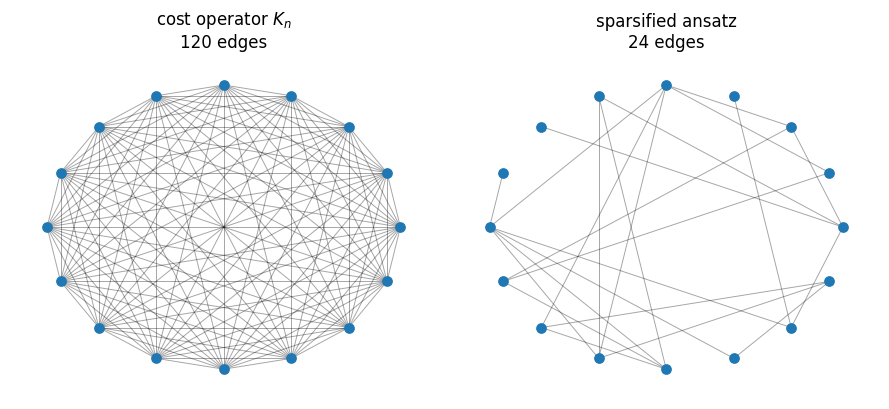

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
positions = nx.circular_layout(cost_graph)

for axis, (title, graph) in zip(
    axes, [("cost operator $K_n$", cost_graph), ("sparsified ansatz", ansatz_graph)]
):
    nx.draw_networkx_edges(graph, positions, ax=axis, alpha=0.35, width=0.7)
    nx.draw_networkx_nodes(graph, positions, ax=axis, node_size=45, node_color="tab:blue")
    axis.set_title(f"{title}\n{graph.number_of_edges()} edges")
    axis.set_axis_off()

fig.tight_layout()
plt.show()

## 4. Angles from `DepthOneScanTrainer` + `EfficientDepthOneEvaluator`

The scan runs on the *dense* cost operator with the *sparse* ansatz, so the landscape is the true
depth-one landscape of the approximate circuit. Since `EfficientDepthOneEvaluator` is exact, the
optimum it returns is the point at which both MPS evaluators are benchmarked, and its energy is
the reference they are scored against.

In [8]:
def scan_angles(operator, sub_graph, num_points=SCAN_POINTS):
    """Depth-one scan with the exact evaluator. Returns (angles, result, trainer)."""
    trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=num_points)
    result = trainer.provide_params(operator, ansatz_circuit=ansatz_circuit(sub_graph))

    return list(result["optimized_params"]), result, trainer


start = perf_counter()
angles, scan_result, scanner = scan_angles(cost_op, ansatz_graph)
scan_time = perf_counter() - start

beta, gamma = angles
print(f"scan over {SCAN_POINTS}x{SCAN_POINTS} points took {scan_time:.2f} s "
      f"({np.mean(scan_result['energy_evaluation_time']) * 1e3:.1f} ms per energy)")
print(f"optimal angles: beta = {beta:.4f}, gamma = {gamma:.4f}")
print(f"reference energy at the optimum: {scan_result['energy']:.6f}")

scan over 15x15 points took 7.47 s (33.2 ms per energy)
optimal angles: beta = 0.4488, gamma = 0.4488
reference energy at the optimum: 4.661396


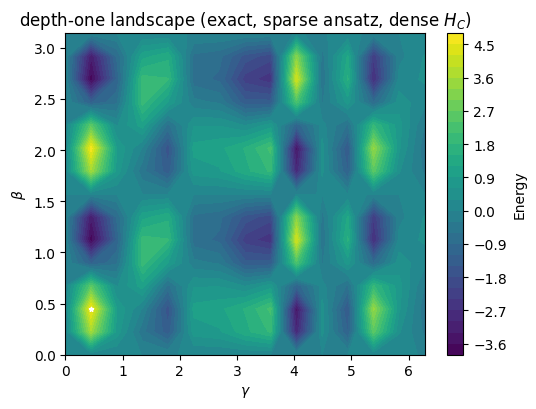

In [9]:
fig, axis = plt.subplots(1, 1, figsize=(5.5, 4.2))
scanner.plot(axis=axis, fig=fig)
axis.set_title("depth-one landscape (exact, sparse ansatz, dense $H_C$)")
fig.tight_layout()
plt.show()

## 5. Cross-check: same backend, same budget, same answer

Three things to confirm before timing anything.

1. The two backends really do carry the same MPS settings.
2. The estimator really does run the number of shots we asked for -- read straight out of the
   result metadata.
3. The sparse ansatz means the same thing to all three evaluators. A convention mismatch, say a
   factor of two in $\gamma$ or a transposed edge list, would show up as a gross disagreement here.

In [10]:
check_aer, check_sampler = make_aer_evaluator(), make_sample_evaluator()

print("MPSAerEvaluator    :", check_aer.to_config()["mps_init_args"])
print("MPSSampleEvaluator :", check_sampler.to_config())

# What the estimator actually ran, from the primitive itself.
probe = check_aer.primitive.run([(qaoa_ansatz(cost_op, reps=1), cost_op, angles)]).result()
print(f"\nestimator shots: {probe[0].metadata['shots']}   (asked for {SHOTS})")

# BackendEstimatorV2 splits the observable with group_commuting(qubit_wise=True) and runs one
# circuit per group. A QAOA cost operator is diagonal, so there is exactly one group.
print(f"measurement bases for {len(cost_op)} Pauli terms: "
      f"{len(cost_op.group_commuting(qubit_wise=True))}")

MPSAerEvaluator    : {'matrix_product_state_max_bond_dimension': 64, 'matrix_product_state_truncation_threshold': 1e-16, 'max_parallel_threads': 10, 'method': 'matrix_product_state'}
MPSSampleEvaluator : {'name': 'MPSSampleEvaluator', 'chi': 64, 'max_parallel_threads': 10, 'shots': 4000}

estimator shots: 4000   (asked for 4000)
measurement bases for 120 Pauli terms: 1


In [11]:
check_graph = weighted_complete_graph(8, seed=7)
check_cost_op = graph_to_operator(check_graph)
check_ansatz = top_weight_subgraph(check_graph, edges_for_degree(8, 3))
check_angles = [0.35, 0.62]

exact_energy = EfficientDepthOneEvaluator().evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_circuit(check_ansatz)
)
aer_energy = make_aer_evaluator(bond_dim=256, shots=200_000).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)
sampled_energy = make_sample_evaluator(bond_dim=256, shots=200_000).evaluate(
    check_cost_op, check_angles, ansatz_circuit=ansatz_operator(check_ansatz)
)

print(f"EfficientDepthOneEvaluator : {exact_energy:.6f}")
print(f"MPSAerEvaluator            : {aer_energy:.6f}   (diff {abs(aer_energy - exact_energy):.2e})")
print(f"MPSSampleEvaluator         : {sampled_energy:.6f}   (diff {abs(sampled_energy - exact_energy):.2e})")

assert abs(aer_energy - exact_energy) < 0.05, "MPSAerEvaluator disagrees with the exact result"
assert abs(sampled_energy - exact_energy) < 0.05, "MPSSampleEvaluator disagrees with the exact result"

EfficientDepthOneEvaluator : 0.746638
MPSAerEvaluator            : 0.736175   (diff 1.05e-02)
MPSSampleEvaluator         : 0.756735   (diff 1.01e-02)


## 6. Head-to-head at the scanned angles

`timed` warms the caches first (`MPSSampleEvaluator` caches the digest of $H_C$ and the per-term
bit indices; the estimator transpiles on first use), then times `REPEATS` further calls -- what an
optimizer would pay per iteration.

Both evaluators are stochastic, so the error reported is the mean absolute deviation from the
exact reference over the repetitions, and `spread` is the standard deviation of the estimates.
Since both sample the same distribution with the same budget, they share one shot-noise floor,
$\sigma_E/\sqrt{\text{shots}}$, computed here from the sampler's own counts.

In [12]:
def timed(func, *args, repeats=REPEATS, **kwargs):
    """Warm up once, then time `repeats` calls. Returns (values, times)."""
    func(*args, **kwargs)

    values, times = [], []
    for _ in range(repeats):
        start = perf_counter()
        values.append(float(np.real(func(*args, **kwargs))))
        times.append(perf_counter() - start)

    return np.array(values), np.array(times)


def head_to_head(
    operator, sub_graph, params, bond_dim=BOND_DIM, shots=SHOTS, repeats=REPEATS
):
    """Accuracy and evaluation time of both Aer evaluators against the exact reference."""
    circuit, ansatz_op = ansatz_circuit(sub_graph), ansatz_operator(sub_graph)

    exact_values, exact_times = timed(
        EfficientDepthOneEvaluator().evaluate,
        operator,
        params,
        ansatz_circuit=circuit,
        repeats=repeats,
    )
    reference = float(exact_values[0])

    aer = make_aer_evaluator(bond_dim=bond_dim, shots=shots)
    aer_values, aer_times = timed(
        aer.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    sampler = make_sample_evaluator(bond_dim=bond_dim, shots=shots)
    sampled_values, sampled_times = timed(
        sampler.evaluate, operator, params, ansatz_circuit=ansatz_op, repeats=repeats
    )

    # Both sample the same distribution, so one shot-noise scale covers both.
    per_sample = np.array(sampler.energies(sampler.get_results_from_last_iteration()["counts"]))
    shot_noise = float(per_sample.std() / np.sqrt(shots))

    return {
        "ansatz_edges": sub_graph.number_of_edges(),
        "cost_terms": len(operator),
        "reference": reference,
        "exact_time": float(np.median(exact_times)),
        "aer_energy": float(aer_values.mean()),
        "aer_error": float(np.abs(aer_values - reference).mean()),
        "aer_spread": float(aer_values.std()),
        "aer_time": float(np.median(aer_times)),
        "sampler_energy": float(sampled_values.mean()),
        "sampler_error": float(np.abs(sampled_values - reference).mean()),
        "sampler_spread": float(sampled_values.std()),
        "sampler_time": float(np.median(sampled_times)),
        "shot_noise": shot_noise,
    }

In [13]:
main = head_to_head(cost_op, ansatz_graph, angles)

print(f"n = {NUM_QUBITS} qubits, {main['cost_terms']} cost terms, "
      f"{main['ansatz_edges']} ansatz edges, chi = {BOND_DIM}, shots = {SHOTS}")
print(f"angles from the scan: beta = {beta:.4f}, gamma = {gamma:.4f}")
print()
print(f"{'evaluator':<28}{'energy':>12}{'abs. error':>13}{'spread':>12}{'time [s]':>11}")
print("-" * 76)
print(f"{'EfficientDepthOne (exact)':<28}{main['reference']:>12.5f}{'-':>13}{'-':>12}"
      f"{main['exact_time']:>11.4f}")
print(f"{'MPSAerEvaluator':<28}{main['aer_energy']:>12.5f}{main['aer_error']:>13.2e}"
      f"{main['aer_spread']:>12.2e}{main['aer_time']:>11.4f}")
print(f"{'MPSSampleEvaluator':<28}{main['sampler_energy']:>12.5f}{main['sampler_error']:>13.2e}"
      f"{main['sampler_spread']:>12.2e}{main['sampler_time']:>11.4f}")
print()
print(f"shared shot-noise floor sigma_E/sqrt(shots): {main['shot_noise']:.3e}")
print(f"time ratio sampler/estimator:                {main['sampler_time'] / main['aer_time']:.2f}")

n = 16 qubits, 120 cost terms, 24 ansatz edges, chi = 64, shots = 4000
angles from the scan: beta = 0.4488, gamma = 0.4488

evaluator                         energy   abs. error      spread   time [s]
----------------------------------------------------------------------------
EfficientDepthOne (exact)        4.66140            -           -     0.0390
MPSAerEvaluator                  4.64734     7.02e-02    7.98e-02     0.8234
MPSSampleEvaluator               4.78445     1.23e-01    7.35e-02     0.7564

shared shot-noise floor sigma_E/sqrt(shots): 1.411e-01
time ratio sampler/estimator:                0.92


Both errors should sit at the shared shot-noise floor, within the scatter of `REPEATS` samples --
that is the expected outcome once the budgets are matched, and it is worth confirming before
reading anything into the timings. What is left to compare is the wall clock.

## 7. Accuracy against cost

Both evaluators have the same knob -- the shot budget -- so the error-versus-time front is the
honest comparison. Both should fall on the same $\sigma_E/\sqrt{\text{shots}}$ line in the error
direction; the separation, if any, is horizontal.

In [14]:
shot_counts = [250, 1000, 4000, 16000]
main_operator = ansatz_operator(ansatz_graph)
reference = main["reference"]

fronts = {"MPSAerEvaluator": [], "MPSSampleEvaluator": []}
for shots in shot_counts:
    for name, factory in [
        ("MPSAerEvaluator", make_aer_evaluator),
        ("MPSSampleEvaluator", make_sample_evaluator),
    ]:
        evaluator = factory(bond_dim=BOND_DIM, shots=shots)
        values, times = timed(
            evaluator.evaluate, cost_op, angles, ansatz_circuit=main_operator, repeats=REPEATS
        )
        fronts[name].append(
            (shots, float(np.abs(values - reference).mean()), float(np.median(times)))
        )
        print(f"{name:<20} shots={shots:6d}  error={fronts[name][-1][1]:.3e}  "
              f"time={fronts[name][-1][2]:.3f} s")

sigma_energy = main["shot_noise"] * np.sqrt(SHOTS)
print(f"\nstd of H_C(x) over the samples: sigma_E = {sigma_energy:.3f}")

MPSAerEvaluator      shots=   250  error=1.658e-01  time=0.203 s
MPSSampleEvaluator   shots=   250  error=4.279e-01  time=0.195 s
MPSAerEvaluator      shots=  1000  error=3.901e-01  time=0.331 s
MPSSampleEvaluator   shots=  1000  error=1.142e-01  time=0.307 s
MPSAerEvaluator      shots=  4000  error=1.056e-01  time=0.937 s
MPSSampleEvaluator   shots=  4000  error=7.979e-02  time=1.001 s
MPSAerEvaluator      shots= 16000  error=4.472e-02  time=2.960 s
MPSSampleEvaluator   shots= 16000  error=7.343e-02  time=3.232 s

std of H_C(x) over the samples: sigma_E = 8.921


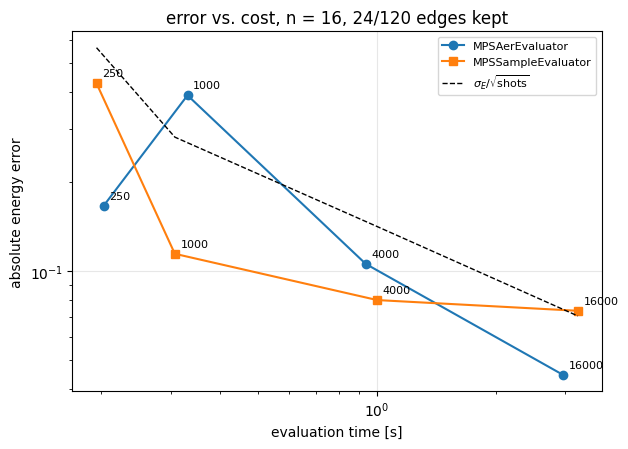

In [15]:
fig, axis = plt.subplots(1, 1, figsize=(6.4, 4.6))

for (name, rows), marker in zip(fronts.items(), ["o-", "s-"]):
    axis.plot([row[2] for row in rows], [row[1] for row in rows], marker, label=name)
    for shots, error, duration in rows:
        axis.annotate(f"{shots}", (duration, error), textcoords="offset points",
                      xytext=(4, 5), fontsize=8)

axis.plot([row[2] for row in fronts["MPSSampleEvaluator"]],
          sigma_energy / np.sqrt(np.array(shot_counts, dtype=float)),
          "k--", lw=1, label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")

axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("evaluation time [s]")
axis.set_ylabel("absolute energy error")
axis.set_title(f"error vs. cost, n = {NUM_QUBITS}, "
               f"{main['ansatz_edges']}/{main['cost_terms']} edges kept")
axis.legend(fontsize=8)
axis.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Ansatz sparsity sweep

The cost operator stays fully connected while the ansatz grows from a few percent of the edges up
to the full graph. This is the second half of the hypothesis as a sweep: if sampling pays off for
a sparse ansatz, the gap should be widest at the left edge.

In [16]:
total_edges = cost_graph.number_of_edges()
fractions = [0.03, 0.06, 0.12, 0.25, 0.5, 0.75, 1.0]
sparsity_rows = []

for fraction in fractions:
    sub_graph = top_weight_subgraph(cost_graph, max(1, int(round(fraction * total_edges))))
    sweep_angles, _, _ = scan_angles(cost_op, sub_graph, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        cost_op, sub_graph, sweep_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=3,
    )
    row["fraction"] = sub_graph.number_of_edges() / total_edges
    sparsity_rows.append(row)

    print(f"edges={row['ansatz_edges']:4d} ({row['fraction']:5.1%})  "
          f"estimator: {row['aer_time']:6.3f} s / err {row['aer_error']:.2e}   "
          f"sampler: {row['sampler_time']:6.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['aer_time']:.2f}")

edges=  10 ( 8.3%)  estimator:  0.429 s / err 2.04e-01   sampler:  0.339 s / err 1.12e-01   ratio 0.79
edges=  12 (10.0%)  estimator:  0.419 s / err 1.55e-01   sampler:  0.355 s / err 1.34e-01   ratio 0.85
edges=  16 (13.3%)  estimator:  0.472 s / err 1.03e-01   sampler:  0.485 s / err 8.17e-02   ratio 1.03
edges=  30 (25.0%)  estimator:  0.781 s / err 9.69e-01   sampler:  0.805 s / err 6.79e-01   ratio 1.03
edges=  60 (50.0%)  estimator:  0.963 s / err 5.11e-01   sampler:  0.971 s / err 7.21e-01   ratio 1.01
edges=  90 (75.0%)  estimator:  1.231 s / err 1.57e-01   sampler:  1.282 s / err 1.95e-01   ratio 1.04
edges= 120 (100.0%)  estimator:  1.351 s / err 6.55e-01   sampler:  1.321 s / err 8.63e-02   ratio 0.98


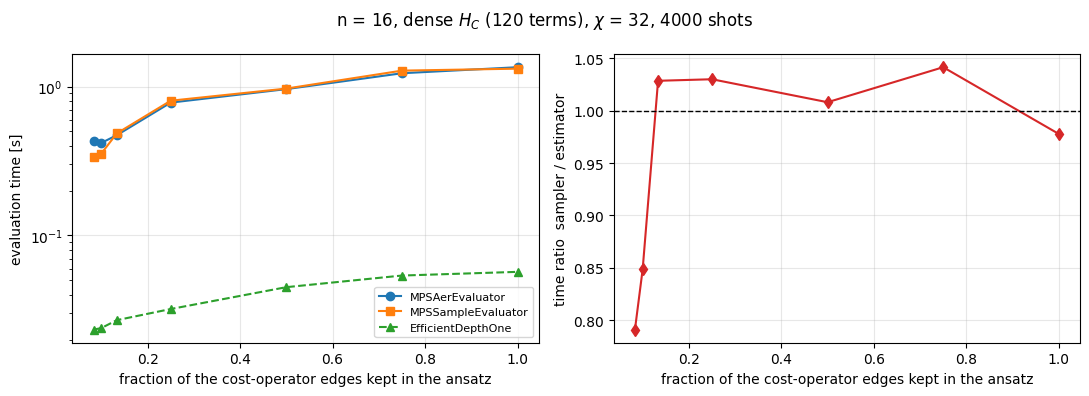

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
edge_fraction = [row["fraction"] for row in sparsity_rows]

axes[0].plot(edge_fraction, [row["aer_time"] for row in sparsity_rows], "o-",
             label="MPSAerEvaluator")
axes[0].plot(edge_fraction, [row["sampler_time"] for row in sparsity_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].plot(edge_fraction, [row["exact_time"] for row in sparsity_rows], "^--",
             label="EfficientDepthOne")
axes[0].set_yscale("log")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

axes[1].plot(edge_fraction,
             [row["sampler_time"] / row["aer_time"] for row in sparsity_rows], "d-",
             color="tab:red")
axes[1].axhline(1.0, color="k", lw=1, ls="--")
axes[1].set_ylabel("time ratio  sampler / estimator")

for axis in axes:
    axis.set_xlabel("fraction of the cost-operator edges kept in the ansatz")
    axis.grid(alpha=0.3)

fig.suptitle(f"n = {NUM_QUBITS}, dense $H_C$ ({total_edges} terms), "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

## 9. Cost-operator density sweep

The other half of the hypothesis, and the one the previous sweep cannot see: hold the ansatz fixed
and sparse, and vary the **density of $H_C$** instead. This is where the two evaluators genuinely
do different work -- the estimator scores the terms with NumPy over the shot array, the sampler
with a Python loop over the unique bit strings -- so it is the sweep that decides whether a dense
cost operator favours one of them.

The reference energy changes at every point, so the shot-noise floor is plotted alongside the
errors rather than a single number.

In [18]:
density_graph = weighted_complete_graph(DENSITY_QUBITS, seed=SEED)
density_ansatz = top_weight_subgraph(
    density_graph, edges_for_degree(DENSITY_QUBITS, MEAN_DEGREE)
)
density_total = density_graph.number_of_edges()
density_rng = np.random.default_rng(SEED)
all_edges = list(density_graph.edges(data=True))

density_rows = []
for fraction in [0.1, 0.25, 0.5, 0.75, 1.0]:
    keep = max(1, int(round(fraction * density_total)))
    chosen = density_rng.choice(len(all_edges), size=keep, replace=False)

    partial = nx.Graph()
    partial.add_nodes_from(density_graph.nodes())
    partial.add_edges_from(all_edges[index] for index in chosen)
    partial_op = graph_to_operator(partial)

    density_angles, _, _ = scan_angles(partial_op, density_ansatz, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        partial_op, density_ansatz, density_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=3,
    )
    density_rows.append(row)

    print(f"terms={row['cost_terms']:5d} ({fraction:5.0%} of $K_n$)  "
          f"estimator: {row['aer_time']:6.3f} s / err {row['aer_error']:.2e}   "
          f"sampler: {row['sampler_time']:6.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['aer_time']:.2f}")

terms=   28 (  10% of $K_n$)  estimator:  0.867 s / err 1.52e-01   sampler:  0.829 s / err 1.34e-01   ratio 0.96
terms=   69 (  25% of $K_n$)  estimator:  0.948 s / err 6.13e-01   sampler:  0.930 s / err 6.18e-01   ratio 0.98
terms=  138 (  50% of $K_n$)  estimator:  1.117 s / err 2.77e-01   sampler:  1.065 s / err 3.15e-01   ratio 0.95
terms=  207 (  75% of $K_n$)  estimator:  1.268 s / err 1.81e-01   sampler:  1.116 s / err 2.74e-01   ratio 0.88
terms=  276 ( 100% of $K_n$)  estimator:  1.433 s / err 5.40e-01   sampler:  1.265 s / err 8.71e-01   ratio 0.88


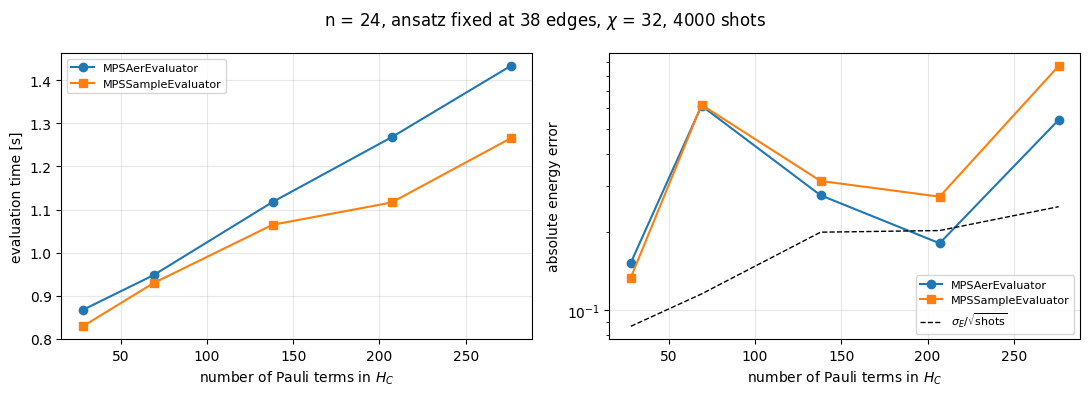

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
term_counts = [row["cost_terms"] for row in density_rows]

axes[0].plot(term_counts, [row["aer_time"] for row in density_rows], "o-",
             label="MPSAerEvaluator")
axes[0].plot(term_counts, [row["sampler_time"] for row in density_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

axes[1].plot(term_counts, [row["aer_error"] for row in density_rows], "o-",
             label="MPSAerEvaluator")
axes[1].plot(term_counts, [row["sampler_error"] for row in density_rows], "s-",
             label="MPSSampleEvaluator")
axes[1].plot(term_counts, [row["shot_noise"] for row in density_rows], "k--", lw=1,
             label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")
axes[1].set_yscale("log")
axes[1].set_ylabel("absolute energy error")
axes[1].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("number of Pauli terms in $H_C$")
    axis.grid(alpha=0.3)

fig.suptitle(f"n = {DENSITY_QUBITS}, ansatz fixed at {density_ansatz.number_of_edges()} edges, "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

The circuit is identical at every point of this sweep, so the *slopes* in the left panel are pure
per-term post-processing cost: whichever line rises faster pays more for a dense $H_C$. In our runs
it is the estimator's, by roughly 50 % per term -- so the sampler's relative advantage *grows* as
$H_C$ densifies. That is the direction the hypothesis predicts, even though the reason is
prosaic: both measure in one basis, and the difference is only in how the shots are scored.

## 10. Scaling with the size of the register

Both knobs at once: the mean degree of the ansatz is held fixed while $n$ grows, so the cost
operator densifies as $n^2$ while the ansatz only grows as $n$ -- the asymptotic version of the
hypothesis. The angles are re-scanned at every size.

Note that both evaluators share the same truncation error here: a sparse but *long-range* ansatz
(the top-$|w|$ couplings are spread over the whole register) generates more entanglement than
$\chi$ = `SWEEP_BOND_DIM` can hold as $n$ grows, so the errors of both drift above the shot-noise
floor together. That is a statement about the shared backend, not about either estimator.

In [20]:
sizes = [8, 12, 16, 20, 24, 28, 32, 40]
scaling_rows = []

for num_qubits in sizes:
    graph = weighted_complete_graph(num_qubits, seed=SEED)
    operator = graph_to_operator(graph)
    sub_graph = top_weight_subgraph(graph, edges_for_degree(num_qubits, MEAN_DEGREE))

    size_angles, _, _ = scan_angles(operator, sub_graph, num_points=SWEEP_SCAN_POINTS)
    row = head_to_head(
        operator, sub_graph, size_angles,
        bond_dim=SWEEP_BOND_DIM, shots=SWEEP_SHOTS, repeats=3,
    )
    row["num_qubits"] = num_qubits
    scaling_rows.append(row)

    print(f"n={num_qubits:3d}  terms={row['cost_terms']:5d}  ansatz={row['ansatz_edges']:4d}  "
          f"estimator: {row['aer_time']:6.3f} s / err {row['aer_error']:.2e}   "
          f"sampler: {row['sampler_time']:6.3f} s / err {row['sampler_error']:.2e}   "
          f"ratio {row['sampler_time'] / row['aer_time']:.2f}")

n=  8  terms=   28  ansatz=  12  estimator:  0.116 s / err 6.00e-02   sampler:  0.142 s / err 1.76e-02   ratio 1.23
n= 12  terms=   66  ansatz=  18  estimator:  0.246 s / err 7.78e-02   sampler:  0.232 s / err 6.15e-02   ratio 0.94
n= 16  terms=  120  ansatz=  24  estimator:  0.734 s / err 1.12e-01   sampler:  0.676 s / err 1.58e-01   ratio 0.92
n= 20  terms=  190  ansatz=  30  estimator:  0.995 s / err 1.69e-01   sampler:  0.917 s / err 3.19e-01   ratio 0.92
n= 24  terms=  276  ansatz=  38  estimator:  1.429 s / err 8.11e-01   sampler:  1.258 s / err 9.99e-01   ratio 0.88
n= 28  terms=  378  ansatz=  44  estimator:  2.143 s / err 1.53e-01   sampler:  1.792 s / err 1.64e-01   ratio 0.84
n= 32  terms=  496  ansatz=  51  estimator:  2.722 s / err 2.09e+00   sampler:  2.487 s / err 2.20e+00   ratio 0.91
n= 40  terms=  780  ansatz=  64  estimator:  4.196 s / err 2.38e-01   sampler:  3.828 s / err 2.06e-01   ratio 0.91


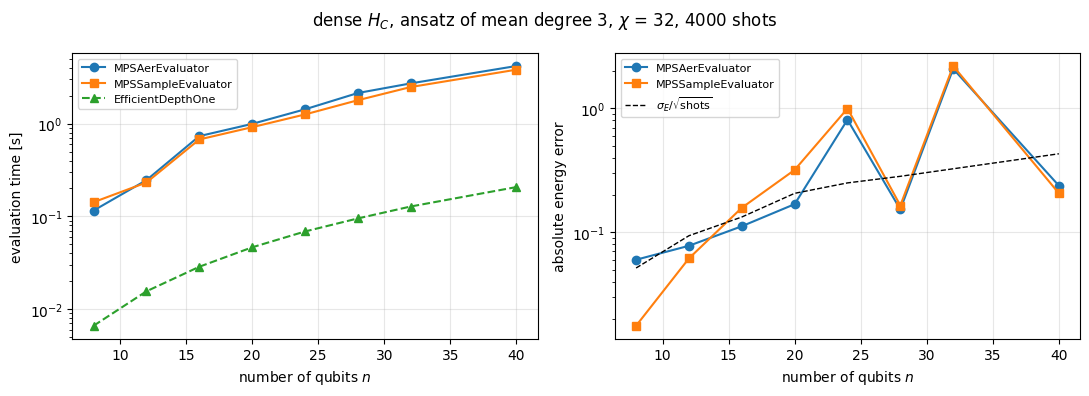

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
qubit_counts = [row["num_qubits"] for row in scaling_rows]

axes[0].plot(qubit_counts, [row["aer_time"] for row in scaling_rows], "o-",
             label="MPSAerEvaluator")
axes[0].plot(qubit_counts, [row["sampler_time"] for row in scaling_rows], "s-",
             label="MPSSampleEvaluator")
axes[0].plot(qubit_counts, [row["exact_time"] for row in scaling_rows], "^--",
             label="EfficientDepthOne")
axes[0].set_yscale("log")
axes[0].set_ylabel("evaluation time [s]")
axes[0].legend(fontsize=8)

axes[1].plot(qubit_counts, [row["aer_error"] for row in scaling_rows], "o-",
             label="MPSAerEvaluator")
axes[1].plot(qubit_counts, [row["sampler_error"] for row in scaling_rows], "s-",
             label="MPSSampleEvaluator")
axes[1].plot(qubit_counts, [row["shot_noise"] for row in scaling_rows], "k--", lw=1,
             label=r"$\sigma_E/\sqrt{\mathrm{shots}}$")
axes[1].set_yscale("log")
axes[1].set_ylabel("absolute energy error")
axes[1].legend(fontsize=8)

for axis in axes:
    axis.set_xlabel("number of qubits $n$")
    axis.grid(alpha=0.3)

fig.suptitle(f"dense $H_C$, ansatz of mean degree {MEAN_DEGREE}, "
             f"$\\chi$ = {SWEEP_BOND_DIM}, {SWEEP_SHOTS} shots")
fig.tight_layout()
plt.show()

## 11. Where the sampler's time goes

Both evaluators pay the same price for the circuit -- same backend, same gates, same shots -- so
whatever separates them lives in the post-processing. For `MPSSampleEvaluator` that is
`energies()`: a Python loop over the unique bit strings, scoring $H_C(x)$ term by term, i.e.
`unique samples` $\times$ `number of Pauli terms` operations. `BackendEstimatorV2` has its own
per-term pass over the same counts, which section 9 showed to be the more expensive of the two;
this cell puts a number on the sampler's half.

In [22]:
sampler = make_sample_evaluator()
_, total_times = timed(sampler.evaluate, cost_op, angles, ansatz_circuit=main_operator)
counts = sampler.get_results_from_last_iteration()["counts"]

loop_times = []
for _ in range(REPEATS):
    start = perf_counter()
    sampler.energies(counts)
    loop_times.append(perf_counter() - start)

total = float(np.median(total_times))
loop = float(np.median(loop_times))

print(f"unique bit strings out of {SHOTS} shots : {len(counts)}")
print(f"total evaluation                       : {total:.3f} s")
print(f"  Python energy loop                   : {loop:.3f} s  ({loop / total:.0%})")
print(f"  Aer circuit + sampling               : {total - loop:.3f} s  ({1 - loop / total:.0%})")

unique bit strings out of 4000 shots : 3447
total evaluation                       : 0.729 s
  Python energy loop                   : 0.190 s  (26%)
  Aer circuit + sampling               : 0.539 s  (74%)


## 12. Reading the results

Numbers are machine-dependent, so re-run before quoting them. The structure the sweeps expose:

**Accuracy is a tie, by construction.** Once the bond dimension, the truncation threshold, the
thread count and the shot budget are matched, both evaluators sample the same distribution with
the same budget and land on the same $\sigma_E/\sqrt{\text{shots}}$ floor. Neither is "more
accurate" than the other; with only a handful of repetitions per point, which one looks better at
any given point is itself noise. Where the errors of both drift above the floor (large $n$ in
section 10) the cause is shared MPS truncation: the top-$|w|$ ansatz is sparse but long-range, so
it entangles more than $\chi$ can hold.

**The comparison is therefore purely about wall clock, and the hypothesis holds -- modestly.**
`MPSSampleEvaluator` came out ahead at essentially every point, and its margin moves the way the
hypothesis predicts along both axes: it is widest for a sparse ansatz on a dense cost operator and
closes to a dead heat as the ansatz densifies (section 8) or as $H_C$ thins out (section 9). The
margin is on the order of 10-15 %, not a factor. It is bounded by the fact that both evaluators
run the *same* circuit for the *same* number of shots on the *same* backend, and that shared
simulation is the bulk of the wall clock.

**The mechanism is not the one the hypothesis assumes.** The estimator never contracts anything
against $H_C$: a QAOA cost operator is diagonal, so `group_commuting(qubit_wise=True)` returns a
single group (section 5) and `BackendEstimatorV2` measures it in one basis with one circuit --
exactly what the sampler does. The whole difference is how the shots are scored afterwards, and
the density sweep of section 9 measures both slopes: on this machine the estimator's per-term cost
is the larger one, which is why a denser $H_C$ helps the sampler rather than hurting it. The
"dense cost operator" in the hypothesis is a proxy for "more Pauli terms to score", not for a more
expensive contraction.

**Practical consequences.**

* Never compare these two without pinning `matrix_product_state_truncation_threshold`: the sampler
  inherits Aer's `1e-16`, `MPSAerEvaluator` defaults to `1e-5` (section 1). Left at the defaults
  the "accuracy" comparison measures nothing but the mismatch.
* Choose on features, not on the 10-15 %. `MPSSampleEvaluator` holds the full sample distribution,
  so it can return CVaR (`cvar(energies, alpha)`) instead of the mean; the estimator cannot. If
  CVaR is the objective, the choice is made regardless of timing.
* If the margin is what you are after, `energies()` is the lever: pack the counts into a
  `(unique samples, n)` bit array and evaluate every term with NumPy parity products. That removes
  the sampler's remaining Python-level dependence on the density of $H_C$ (30 % of its wall clock
  at the main operating point, section 11) and widens the gap in exactly the regime this notebook
  is about.
* None of this transfers to the `quimb`-based `MPSEvaluator`, which runs on a different backend
  with a different truncation scheme and its own SWAP handling. Comparing against it measures the
  backends, not the estimators -- which is why this notebook does not.